In [1]:
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from sklearn.metrics import r2_score

In [2]:
PLOT_TITLES = ['NDT-informed Exponential', 'NDT-informed Hyperbolic']

FONT_SIZE_1 = 15
FONT_SIZE_2 = 14
FONT_SIZE_3 = 11

In [3]:
original_cmap = sns.diverging_palette(10, 150, as_cmap=True, s=80, l=40)
num_colors = 256
shift_factor = 0.7
num_lower_pos = int(num_colors * shift_factor)
lower_pos = np.linspace(0, 0.5, num_lower_pos)
upper_pos = np.linspace(0.5, 1, num_colors - num_lower_pos)
new_positions = np.concatenate((lower_pos, upper_pos))
COLOR_BAR = LinearSegmentedColormap.from_list("shifted_cmap", original_cmap(new_positions))

In [4]:
import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

In [5]:
def plot_recovery_heatmap(data_list, param_names, model_names, x_label, color_bar_pos, wspace, plot_name):
    fig, axes = plt.subplots(1, 2, figsize=(8, 3), gridspec_kw={'width_ratios': [1, 1], 'wspace': wspace})
    for i, ax in enumerate(axes):
        sns.heatmap(
            data_list[i], annot=True, fmt='.2f', annot_kws={"size": FONT_SIZE_3},
            yticklabels=param_names if i == 0 else [],
            xticklabels=model_names, cmap=COLOR_BAR, ax=ax, vmin=0, vmax=1,
            cbar=False, square=True
        )
        ax.set_title(PLOT_TITLES[i], fontsize=FONT_SIZE_1, pad=10)
        if i == 0:
            ax.set_ylabel('Parameter', fontsize=FONT_SIZE_2)
        else:
            ax.set_ylabel('')
        ax.set_xlabel(x_label, fontsize=FONT_SIZE_2)
        ax.tick_params(axis='both', which='major', labelsize=FONT_SIZE_3)
    # Add a single color bar for the entire figure
    cbar_ax = fig.add_axes(color_bar_pos)  # [left, bottom, width, height]
    norm = plt.Normalize(vmin=0, vmax=1)
    sm = plt.cm.ScalarMappable(cmap=COLOR_BAR, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cbar_ax, orientation='vertical')
    # Remove the outline of the color bar
    cbar.outline.set_visible(False)
    # Adjust the font size of the numbers on the color bar
    cbar.ax.tick_params(labelsize=FONT_SIZE_3)

    plt.savefig(
        f'plots/{plot_name}.pdf',
        transparent=True, dpi=600,
        bbox_inches='tight'
    )

## Parameter Recovery 

## Sensitivity to Number of Observations

In [6]:
param_names = [
    r'Threshold ($\theta$)', r'Decay ($\lambda$)',
    r'NDT ($\tau$)', r'Drift rate ($v$)', r'Observation noise ($\sigma_z$)'
]
model_names = [
    r'$N = 100$', r'$N = 250$', r'$N = 500$', r'$N = 1000$'
]
x_label = 'Number of observations'
color_bar_pos = [0.85, 0.11, 0.02, 0.77]
wspace = -0.2

### IF

In [7]:
exp_100_recovery = pd.read_csv('_01_IE/_02_ndt_constrain/_log_normal/_data/Exponential_rec_100.csv', index_col=0).to_numpy()
exp_250_recovery = pd.read_csv('_01_IE/_02_ndt_constrain/_log_normal/_data/Exponential_rec_250.csv', index_col=0).to_numpy()
exp_500_recovery = pd.read_csv('_01_IE/_02_ndt_constrain/_log_normal/_data/Exponential_rec_500.csv', index_col=0).to_numpy()
exp_1000_recovery = pd.read_csv('_01_IE/_02_ndt_constrain/_log_normal/_data/Exponential_rec_1000.csv', index_col=0).to_numpy()
hyper_100_recovery = pd.read_csv('_01_IE/_02_ndt_constrain/_log_normal/_data/Hyperbolic_rec_100.csv', index_col=0).to_numpy()
hyper_250_recovery = pd.read_csv('_01_IE/_02_ndt_constrain/_log_normal/_data/Hyperbolic_rec_250.csv', index_col=0).to_numpy()
hyper_500_recovery = pd.read_csv('_01_IE/_02_ndt_constrain/_log_normal/_data/Hyperbolic_rec_500.csv', index_col=0).to_numpy()
hyper_1000_recovery = pd.read_csv('_01_IE/_02_ndt_constrain/_log_normal/_data/Hyperbolic_rec_1000.csv', index_col=0).to_numpy()

r2_exp = np.array([
    [
        r2_score(exp_100_recovery[:, 0], exp_100_recovery[:, 1]),
        r2_score(exp_250_recovery[:, 0], exp_250_recovery[:, 1]),
        r2_score(exp_500_recovery[:, 0], exp_500_recovery[:, 1]),
        r2_score(exp_1000_recovery[:, 0], exp_1000_recovery[:, 1]),
    ],
    [
        r2_score(exp_100_recovery[:, 2], exp_100_recovery[:, 3]),
        r2_score(exp_250_recovery[:, 2], exp_250_recovery[:, 3]),
        r2_score(exp_500_recovery[:, 2], exp_500_recovery[:, 3]),
        r2_score(exp_1000_recovery[:, 2], exp_1000_recovery[:, 3]),
    ],
    [
        r2_score(exp_100_recovery[:, -2], exp_100_recovery[:, -1]),
        r2_score(exp_250_recovery[:, -2], exp_250_recovery[:, -1]),
        r2_score(exp_500_recovery[:, -2], exp_500_recovery[:, -1]),
        r2_score(exp_1000_recovery[:, -2], exp_1000_recovery[:, -1]),
    ],
    [
        r2_score(exp_100_recovery[:, 4], exp_100_recovery[:, 5]),
        r2_score(exp_250_recovery[:, 4], exp_250_recovery[:, 5]),
        r2_score(exp_500_recovery[:, 4], exp_500_recovery[:, 5]),
        r2_score(exp_1000_recovery[:, 4], exp_1000_recovery[:, 5]),
    ],
    [
        r2_score(exp_100_recovery[:, 6], exp_100_recovery[:, 7]),
        r2_score(exp_250_recovery[:, 6], exp_250_recovery[:, 7]),
        r2_score(exp_500_recovery[:, 6], exp_500_recovery[:, 7]),
        r2_score(exp_1000_recovery[:, 6], exp_1000_recovery[:, 7]),
    ],
])
r2_hyper = np.array([
    [
        r2_score(hyper_100_recovery[:, 0], hyper_100_recovery[:, 1]),
        r2_score(hyper_250_recovery[:, 0], hyper_250_recovery[:, 1]),
        r2_score(hyper_500_recovery[:, 0], hyper_500_recovery[:, 1]),
        r2_score(hyper_1000_recovery[:, 0], hyper_1000_recovery[:, 1]),
    ],
    [
        r2_score(hyper_100_recovery[:, 2], hyper_100_recovery[:, 3]),
        r2_score(hyper_250_recovery[:, 2], hyper_250_recovery[:, 3]),
        r2_score(hyper_500_recovery[:, 2], hyper_500_recovery[:, 3]),
        r2_score(hyper_1000_recovery[:, 2], hyper_1000_recovery[:, 3]),
    ],
    [
        r2_score(hyper_100_recovery[:, -2], hyper_100_recovery[:, -1]),
        r2_score(hyper_250_recovery[:, -2], hyper_250_recovery[:, -1]),
        r2_score(hyper_500_recovery[:, -2], hyper_500_recovery[:, -1]),
        r2_score(hyper_1000_recovery[:, -2], hyper_1000_recovery[:, -1]),
    ],
    [
        r2_score(hyper_100_recovery[:, 4], hyper_100_recovery[:, 5]),
        r2_score(hyper_250_recovery[:, 4], hyper_250_recovery[:, 5]),
        r2_score(hyper_500_recovery[:, 4], hyper_500_recovery[:, 5]),
        r2_score(hyper_1000_recovery[:, 4], hyper_1000_recovery[:, 5]),
    ],
    [
        r2_score(exp_100_recovery[:, 6], exp_100_recovery[:, 7]),
        r2_score(exp_250_recovery[:, 6], exp_250_recovery[:, 7]),
        r2_score(exp_500_recovery[:, 6], exp_500_recovery[:, 7]),
        r2_score(exp_1000_recovery[:, 6], exp_1000_recovery[:, 7]),
    ],
])

data_list = [r2_exp, r2_hyper]

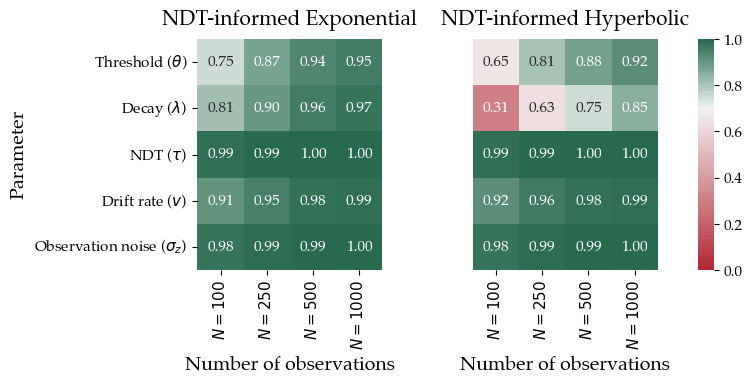

In [8]:
plot_recovery_heatmap(
    data_list, param_names, model_names, x_label, color_bar_pos, wspace, 'IE_num_obs_sensitivity'
)

In [10]:
pd.read_csv('_01_IE/_01_no_constrain/_data/Exponential_rec_100.csv', index_col=0)

,a_true,a_estimate,lambda_true,lambda_estimate,delta_true,delta_estimate,ndt_true,ndt_estimate
0,1.986564,2.307261,0.181913,0.241927,0.581770,0.577847,0.451584,0.313582
1,3.991015,4.000000,0.701940,0.573693,2.764230,3.000000,0.633283,0.639279
2,3.294731,2.502875,1.372519,1.493235,2.858170,2.255086,0.822385,0.881385
3,1.550231,2.052111,0.941671,1.095810,1.043488,1.114878,0.685348,0.597523
4,1.854456,1.811264,0.103943,0.100000,1.259512,1.175902,0.466787,0.532786
...,...,...,...,...,...,...,...,...
995,3.860194,3.214611,0.440877,0.204320,2.261110,2.999997,0.248442,0.419443
996,3.316778,2.516850,0.884495,0.527246,2.678570,3.000000,0.517419,0.594419
997,1.731513,3.954174,1.314251,1.723760,2.883816,2.728449,0.777100,0.591100
998,2.734242,3.236316,0.818809,0.804839,1.475089,1.329165,0.193136,0.087329


In [14]:
exp_100_recovery = pd.read_csv('_01_IE/_01_no_constrain/_data/Exponential_rec_100.csv', index_col=0).to_numpy()
exp_250_recovery = pd.read_csv('_01_IE/_01_no_constrain/_data/Exponential_rec_250.csv', index_col=0).to_numpy()
exp_500_recovery = pd.read_csv('_01_IE/_01_no_constrain/_data/Exponential_rec_500.csv', index_col=0).to_numpy()
exp_1000_recovery = pd.read_csv('_01_IE/_01_no_constrain/_data/Exponential_rec_1000.csv', index_col=0).to_numpy()
hyper_100_recovery = pd.read_csv('_01_IE/_01_no_constrain/_data/Hyperbolic_rec_100.csv', index_col=0).to_numpy()
hyper_250_recovery = pd.read_csv('_01_IE/_01_no_constrain/_data/Hyperbolic_rec_250.csv', index_col=0).to_numpy()
hyper_500_recovery = pd.read_csv('_01_IE/_01_no_constrain/_data/Hyperbolic_rec_500.csv', index_col=0).to_numpy()
hyper_1000_recovery = pd.read_csv('_01_IE/_01_no_constrain/_data/Hyperbolic_rec_1000.csv', index_col=0).to_numpy()

PLOT_TITLES = ['Uninformed Exponential', 'Uninformed Hyperbolic']
param_names = [
    r'Threshold ($\theta$)', r'Decay ($\lambda$)',
    r'NDT ($\tau$)', r'Drift rate ($v$)'
]

r2_exp = np.array([
    [
        r2_score(exp_100_recovery[:, 0], exp_100_recovery[:, 1]),
        r2_score(exp_250_recovery[:, 0], exp_250_recovery[:, 1]),
        r2_score(exp_500_recovery[:, 0], exp_500_recovery[:, 1]),
        r2_score(exp_1000_recovery[:, 0], exp_1000_recovery[:, 1]),
    ],
    [
        r2_score(exp_100_recovery[:, 2], exp_100_recovery[:, 3]),
        r2_score(exp_250_recovery[:, 2], exp_250_recovery[:, 3]),
        r2_score(exp_500_recovery[:, 2], exp_500_recovery[:, 3]),
        r2_score(exp_1000_recovery[:, 2], exp_1000_recovery[:, 3]),
    ],
    [
        r2_score(exp_100_recovery[:, -2], exp_100_recovery[:, -1]),
        r2_score(exp_250_recovery[:, -2], exp_250_recovery[:, -1]),
        r2_score(exp_500_recovery[:, -2], exp_500_recovery[:, -1]),
        r2_score(exp_1000_recovery[:, -2], exp_1000_recovery[:, -1]),
    ],
    [
        r2_score(exp_100_recovery[:, 4], exp_100_recovery[:, 5]),
        r2_score(exp_250_recovery[:, 4], exp_250_recovery[:, 5]),
        r2_score(exp_500_recovery[:, 4], exp_500_recovery[:, 5]),
        r2_score(exp_1000_recovery[:, 4], exp_1000_recovery[:, 5]),
    ],
])
r2_hyper = np.array([
    [
        r2_score(hyper_100_recovery[:, 0], hyper_100_recovery[:, 1]),
        r2_score(hyper_250_recovery[:, 0], hyper_250_recovery[:, 1]),
        r2_score(hyper_500_recovery[:, 0], hyper_500_recovery[:, 1]),
        r2_score(hyper_1000_recovery[:, 0], hyper_1000_recovery[:, 1]),
    ],
    [
        r2_score(hyper_100_recovery[:, 2], hyper_100_recovery[:, 3]),
        r2_score(hyper_250_recovery[:, 2], hyper_250_recovery[:, 3]),
        r2_score(hyper_500_recovery[:, 2], hyper_500_recovery[:, 3]),
        r2_score(hyper_1000_recovery[:, 2], hyper_1000_recovery[:, 3]),
    ],
    [
        r2_score(hyper_100_recovery[:, -2], hyper_100_recovery[:, -1]),
        r2_score(hyper_250_recovery[:, -2], hyper_250_recovery[:, -1]),
        r2_score(hyper_500_recovery[:, -2], hyper_500_recovery[:, -1]),
        r2_score(hyper_1000_recovery[:, -2], hyper_1000_recovery[:, -1]),
    ],
    [
        r2_score(hyper_100_recovery[:, 4], hyper_100_recovery[:, 5]),
        r2_score(hyper_250_recovery[:, 4], hyper_250_recovery[:, 5]),
        r2_score(hyper_500_recovery[:, 4], hyper_500_recovery[:, 5]),
        r2_score(hyper_1000_recovery[:, 4], hyper_1000_recovery[:, 5]),
    ],
])

data_list = [r2_exp, r2_hyper]

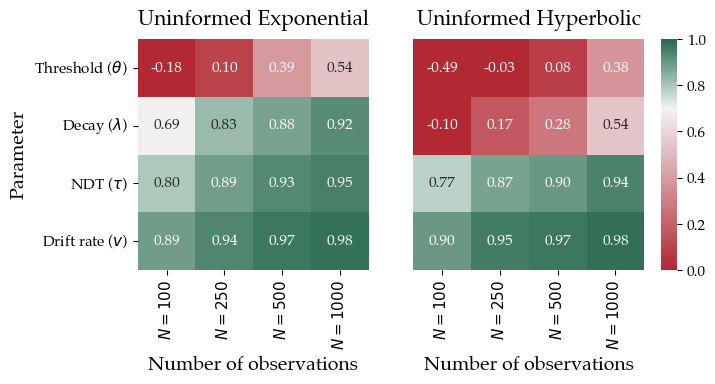

In [15]:
plot_recovery_heatmap(
    data_list, param_names, model_names, x_label, color_bar_pos, wspace, 'IE_num_obs_sensitivity_unifo'
)